In [24]:

# Imports, NLTK Download, and Environment Config

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.tsa.stattools import grangercausalitytests
import statsmodels.api as sm
from scipy import stats
from dotenv import load_dotenv
from warnings import filterwarnings
filterwarnings('ignore')

# Add project root to sys.path to load local custom modules
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)

from collection_data import Data_collection, stock_tups,stack_company_data
from preparation_data import Data_prep
from preprocessing_data import StatefulDataPreprocessor

# Load API Key from your local .env file
load_dotenv()
api_key = os.getenv("ALPHA_VANTAGE_API_KEY")

print("[SUCCESS] Environment and modules successfully loaded!")
print("TensorFlow Version:", tf.__version__)
if api_key:
    print("API Key loaded successfully from .env!")
else:
    print("API Key not found in .env. The collection script will automatically use mock fallback.")

[SUCCESS] Environment and modules successfully loaded!
TensorFlow Version: 2.21.0
API Key loaded successfully from .env!


In [25]:
# Ingest all stock data cleanly using your imported collection_data.py module
company_data = {}
for tup in stock_tups:
    sym, exch, count, owner, ast_t, yf_tick = tup
    collector = Data_collection(sym, exch, count, owner, ast_t, yf_tick)
    df = collector.collect_data(start_date='2020-01-01', end_date='2025-01-01')
    if not df.empty:
        company_data[sym] = df

unified_df = stack_company_data(company_data)
print(f"✅ Ingestion complete. Unified multi-stock shape: {unified_df.shape}")

[*********************100%***********************]  1 of 1 completed


[INFO] Fetching historical news sentiment for RELIANCE (RELIANCE.NS)...


[*********************100%***********************]  1 of 1 completed

[WARN] Alpha Vantage News Sentiment API limit reached or rate-limited for RELIANCE.
[INFO] Generating high-quality mock news sentiment for RELIANCE...
[INFO] Fetching historical news sentiment for ADANIENT (ADANIENT.NS)...



[*********************100%***********************]  1 of 1 completed

...


[*********************100%***********************]  1 of 1 completed

[WARN] Alpha Vantage News Sentiment API limit reached or rate-limited for BANKNIFTY.
[INFO] Generating high-quality mock news sentiment for BANKNIFTY...
[INFO] Fetching historical news sentiment for NIFTY50 (^NSEI)...



[*********************100%***********************]  1 of 1 completed

[WARN] Alpha Vantage News Sentiment API limit reached or rate-limited for NIFTY50.
[INFO] Generating high-quality mock news sentiment for NIFTY50...
[INFO] Fetching historical news sentiment for INDIAVIX (^INDIAVIX)...


[WARN] Alpha Vantage News Sentiment API limit reached or rate-limited for INDIAVIX.
[INFO] Generating high-quality mock news sentiment for INDIAVIX...
✅ Ingestion complete. Unified multi-stock shape: (11125, 12)


In [26]:
# Call your preparation_data.py module cleanly
prep = Data_prep()
df_prepared = prep.prepare_features(unified_df)
print(f"✅ Feature Engineering complete. Prepared shape: {df_prepared.shape}")

✅ Feature Engineering complete. Prepared shape: (11125, 22)


In [27]:
# Call your preprocessing_data.py module cleanly (generates both Copy A and Copy B)
preprocessor = StatefulDataPreprocessor(seq_length=10, target_col='close')
(sequences_a, scaled_a), (sequences_b, scaled_b) = preprocessor.fit_transform_dual(df_prepared)
print("✅ Partitioned dual preprocessed copies created successfully!")

✅ Partitioned dual preprocessed copies created successfully!


In [28]:
# Helper Cell: Define the global symbol-by-symbol inverse scaling utility
import numpy as np

def inverse_close(preprocessor_root, symbol, scaled_preds, is_sentiment=False):
    """
    Inverse-scales scaled 'close' price predictions symbol-by-symbol.
    
    Args:
        preprocessor_root (StatefulDataPreprocessor): Root preprocessor.
        symbol (str): The specific stock symbol.
        scaled_preds (array-like): Scaled values to unscale.
        is_sentiment (bool): True if Copy B (sentiment), False if Copy A (baseline).
    """
    # Select appropriate sub-preprocessor (Copy A or Copy B)
    if is_sentiment:
        prep = preprocessor_root.preprocessor_b
    else:
        prep = preprocessor_root.preprocessor_a
        
    scaler = prep.symbol_scalers[symbol]
    
    # Get numerical columns in exact fitted order
    numerical_cols = [col for col in prep.feature_cols if col not in prep.categorical_cols]
    close_idx = numerical_cols.index('close')
    
    # Handle single scalar inputs
    is_single = False
    if np.isscalar(scaled_preds):
        scaled_preds = np.array([scaled_preds])
        is_single = True
    elif len(scaled_preds.shape) == 0:
        scaled_preds = scaled_preds.reshape(1)
        is_single = True
        
    # Reconstruct dummy matrix for inverse scaling
    dummy = np.zeros((len(scaled_preds), len(numerical_cols)))
    dummy[:, close_idx] = scaled_preds
    
    # Inverse transform and extract close column
    unscaled = scaler.inverse_transform(dummy)[:, close_idx]
    
    return unscaled[0] if is_single else unscaled

In [29]:
# CELL 5: Chronological Data Splitting & Concatenation

import numpy as np

# 1. Chronological Train-test splits for all symbols
train_seqs_base = {}
val_seqs_base = {}
train_seqs_sent = {}
val_seqs_sent = {}

for sym in sequences_a.keys():
    # Baseline Copy A
    X_a, y_a = sequences_a[sym]
    split_idx_a = int(len(X_a) * 0.8)
    train_seqs_base[sym] = (X_a[:split_idx_a], y_a[:split_idx_a])
    val_seqs_base[sym] = (X_a[split_idx_a:], y_a[split_idx_a:])
    
    # Sentiment Copy B
    X_b, y_b = sequences_b[sym]
    split_idx_b = int(len(X_b) * 0.8)
    train_seqs_sent[sym] = (X_b[:split_idx_b], y_b[:split_idx_b])
    val_seqs_sent[sym] = (X_b[split_idx_b:], y_b[split_idx_b:])

# 2. Concatenate training sequences of ALL stocks into unified global matrices
X_train_base = np.concatenate([X for sym, (X, y) in train_seqs_base.items() if len(X) > 0], axis=0)
y_train_base = np.concatenate([y for sym, (X, y) in train_seqs_base.items() if len(y) > 0], axis=0)

X_train_sent = np.concatenate([X for sym, (X, y) in train_seqs_sent.items() if len(X) > 0], axis=0)
y_train_sent = np.concatenate([y for sym, (X, y) in train_seqs_sent.items() if len(y) > 0], axis=0)

# 3. Concatenate validation sequences of ALL stocks into unified global matrices
X_val_base = np.concatenate([X for sym, (X, y) in val_seqs_base.items() if len(X) > 0], axis=0)
y_val_base = np.concatenate([y for sym, (X, y) in val_seqs_base.items() if len(y) > 0], axis=0)

X_val_sent = np.concatenate([X for sym, (X, y) in val_seqs_sent.items() if len(X) > 0], axis=0)
y_val_sent = np.concatenate([y for sym, (X, y) in val_seqs_sent.items() if len(y) > 0], axis=0)

# 4. Extract and align actual close prices globally across all symbols (Unscaled!)
y_val_real_dict = {}
last_close_val_real_dict = {}

# Fetch the 'close' index within feature_cols to extract it from the sequence inputs
close_idx_a = preprocessor.preprocessor_a.feature_cols.index('close')

for sym in sequences_a.keys():
    X_v, y_v = val_seqs_base[sym]
    if len(X_v) == 0:
        continue
    
    # Unscale validation targets (actual next-day close) symbol-by-symbol
    y_v_unscaled = inverse_close(preprocessor, sym, y_v, is_sentiment=False)
    y_val_real_dict[sym] = y_v_unscaled
    
    # Unscale the last close price in the sequence (current day close) symbol-by-symbol
    last_close_scaled = X_v[:, -1, close_idx_a]
    last_close_unscaled = inverse_close(preprocessor, sym, last_close_scaled, is_sentiment=False)
    last_close_val_real_dict[sym] = last_close_unscaled

# Concatenate all actual arrays into single, global 1D evaluation arrays
y_val_real = np.concatenate(list(y_val_real_dict.values()))
last_close_val_real = np.concatenate(list(last_close_val_real_dict.values()))
actual_direction = np.sign(y_val_real - last_close_val_real)

print(f"✅ Splits Complete.")
print(f"Global X_train_base: {X_train_base.shape} | X_val_base: {X_val_base.shape}")
print(f"Global Evaluation Target y_val_real: {y_val_real.shape} | last_close_val_real: {last_close_val_real.shape}")

✅ Splits Complete.
Global X_train_base: (8824, 10, 23) | X_val_base: (2211, 10, 23)
Global Evaluation Target y_val_real: (2211,) | last_close_val_real: (2211,)


In [30]:
# CELL 6: Model 1 - OLS Linear Regression

print("\n--- Fitting OLS Regression Models globally ---")
from sklearn.linear_model import LinearRegression

# Flatten time steps for standard linear regression
X_train_base_flat = X_train_base.reshape(len(X_train_base), -1)
X_train_sent_flat = X_train_sent.reshape(len(X_train_sent), -1)

# Fit global regression models
ols_base = LinearRegression().fit(X_train_base_flat, y_train_base)
ols_sent = LinearRegression().fit(X_train_sent_flat, y_train_sent)

# A. Baseline OLS validation predictions symbol-by-symbol
ols_base_preds_dict = {}
for sym, (X_v, y_v) in val_seqs_base.items():
    if len(X_v) == 0:
        continue
    preds_scaled = ols_base.predict(X_v.reshape(len(X_v), -1))
    preds_unscaled = inverse_close(preprocessor, sym, preds_scaled, is_sentiment=False)
    ols_base_preds_dict[sym] = preds_unscaled
ols_base_preds = np.concatenate(list(ols_base_preds_dict.values()))

# B. Sentiment-Enhanced OLS validation predictions symbol-by-symbol
ols_sent_preds_dict = {}
for sym, (X_v, y_v) in val_seqs_sent.items():
    if len(X_v) == 0:
        continue
    preds_scaled = ols_sent.predict(X_v.reshape(len(X_v), -1))
    preds_unscaled = inverse_close(preprocessor, sym, preds_scaled, is_sentiment=True)
    ols_sent_preds_dict[sym] = preds_unscaled
ols_sent_preds = np.concatenate(list(ols_sent_preds_dict.values()))

# Calculate Directional Accuracy
dir_ols_base = np.mean(actual_direction == np.sign(ols_base_preds - last_close_val_real)) * 100
dir_ols_sent = np.mean(actual_direction == np.sign(ols_sent_preds - last_close_val_real)) * 100

print(f"OLS Baseline MSE: {mean_squared_error(y_val_real, ols_base_preds):.4f} | R2: {r2_score(y_val_real, ols_base_preds):.4f} | DirAcc: {dir_ols_base:.2f}%")
print(f"OLS Enhanced MSE: {mean_squared_error(y_val_real, ols_sent_preds):.4f} | R2: {r2_score(y_val_real, ols_sent_preds):.4f} | DirAcc: {dir_ols_sent:.2f}%")


--- Fitting OLS Regression Models globally ---
OLS Baseline MSE: 41979.1257 | R2: 0.9998 | DirAcc: 49.34%
OLS Enhanced MSE: 42238.5363 | R2: 0.9998 | DirAcc: 48.71%


In [31]:
# CELL 7: Model 2 - XGBoost Regressor

print("\n--- Fitting XGBoost Models globally ---")

# Train global XGBoost models
xgb_base = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_base.fit(X_train_base_flat, y_train_base)

xgb_sent = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_sent.fit(X_train_sent_flat, y_train_sent)

# A. Baseline XGBoost validation predictions symbol-by-symbol
xgb_base_preds_dict = {}
for sym, (X_v, y_v) in val_seqs_base.items():
    if len(X_v) == 0:
        continue
    preds_scaled = xgb_base.predict(X_v.reshape(len(X_v), -1))
    preds_unscaled = inverse_close(preprocessor, sym, preds_scaled, is_sentiment=False)
    xgb_base_preds_dict[sym] = preds_unscaled
xgb_base_preds = np.concatenate(list(xgb_base_preds_dict.values()))

# B. Sentiment-Enhanced XGBoost validation predictions symbol-by-symbol
xgb_sent_preds_dict = {}
for sym, (X_v, y_v) in val_seqs_sent.items():
    if len(X_v) == 0:
        continue
    preds_scaled = xgb_sent.predict(X_v.reshape(len(X_v), -1))
    preds_unscaled = inverse_close(preprocessor, sym, preds_scaled, is_sentiment=True)
    xgb_sent_preds_dict[sym] = preds_unscaled
xgb_sent_preds = np.concatenate(list(xgb_sent_preds_dict.values()))

# Calculate Directional Accuracy
dir_xgb_base = np.mean(actual_direction == np.sign(xgb_base_preds - last_close_val_real)) * 100
dir_xgb_sent = np.mean(actual_direction == np.sign(xgb_sent_preds - last_close_val_real)) * 100

print(f"XGB Baseline MSE: {mean_squared_error(y_val_real, xgb_base_preds):.4f} | R2: {r2_score(y_val_real, xgb_base_preds):.4f} | DirAcc: {dir_xgb_base:.2f}%")
print(f"XGB Enhanced MSE: {mean_squared_error(y_val_real, xgb_sent_preds):.4f} | R2: {r2_score(y_val_real, xgb_sent_preds):.4f} | DirAcc: {dir_xgb_sent:.2f}%")


--- Fitting XGBoost Models globally ---
XGB Baseline MSE: 239089.7701 | R2: 0.9991 | DirAcc: 48.26%
XGB Enhanced MSE: 232990.2169 | R2: 0.9991 | DirAcc: 49.21%


In [32]:
# CELL 8: Model 3 - Stateless Transformer Encoder

import json
import keras_tuner as kt
from sklearn.metrics import mean_squared_error, r2_score
from model import Transformer_Encoder, Static_Positional_Embedding, Transformer_Encoder_Model

print("\n--- Training Transformer Encoders globally ---")

# 1. Load best hyperparameters with safe default fallback
try:
    with open("best_hps.json", "r") as f:
        hps = json.load(f)
except FileNotFoundError:
    hps = {
        "reg_type": "l1_l2",
        "l1": 1e-5,
        "l2": 1e-5,
        "dropout_rate": 0.4,
        "Learning_Rate": 0.001,
        "Batch_size": 32,
        "epochs": 20
    }

hp = kt.HyperParameters()
for k, v in hps.items():
    # Use Learning_Rate if present, fallback to Leraning_Rate typo if needed
    if k == "Leraning_Rate" and "Learning_Rate" not in hps:
        hp.values["Learning_Rate"] = v
    else:
        hp.values[k] = v

batch_size = hps.get("Batch_size", 32)
epochs = hps.get("epochs", 20)

# -----------------------------------------------------------------
# A. Train Baseline Transformer
# -----------------------------------------------------------------
print("   * Training Baseline Transformer...")
hypermodel_base = Transformer_Encoder_Model(
    seq_len=X_train_base.shape[1],
    num_features=X_train_base.shape[2]
)
transformer_base = hypermodel_base.build(hp)

transformer_base.fit(
    X_train_base, y_train_base,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    verbose=1
)

# -----------------------------------------------------------------
# B. Train Sentiment-Enhanced Transformer
# -----------------------------------------------------------------
print("   * Training Sentiment-Enhanced Transformer...")
hypermodel_sent = Transformer_Encoder_Model(
    seq_len=X_train_sent.shape[1],
    num_features=X_train_sent.shape[2]
)
transformer_sent = hypermodel_sent.build(hp)

transformer_sent.fit(
    X_train_sent, y_train_sent,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    verbose=1
)

# -----------------------------------------------------------------
# C. Baseline Transformer validation predictions symbol-by-symbol
# -----------------------------------------------------------------
# We loop symbol-by-symbol ONLY to apply each stock's unique scaler
transformer_base_preds_dict = {}
for sym, (X_v, y_v) in val_seqs_base.items():
    if len(X_v) == 0:
        continue
    preds_scaled = transformer_base.predict(X_v, batch_size=batch_size, verbose=0).flatten()
    preds_unscaled = inverse_close(preprocessor, sym, preds_scaled, is_sentiment=False)
    transformer_base_preds_dict[sym] = preds_unscaled
transformer_base_preds = np.concatenate(list(transformer_base_preds_dict.values()))

# -----------------------------------------------------------------
# D. Sentiment-Enhanced Transformer validation predictions symbol-by-symbol
# -----------------------------------------------------------------
transformer_sent_preds_dict = {}
for sym, (X_v, y_v) in val_seqs_sent.items():
    if len(X_v) == 0:
        continue
    preds_scaled = transformer_sent.predict(X_v, batch_size=batch_size, verbose=0).flatten()
    preds_unscaled = inverse_close(preprocessor, sym, preds_scaled, is_sentiment=True)
    transformer_sent_preds_dict[sym] = preds_unscaled
transformer_sent_preds = np.concatenate(list(transformer_sent_preds_dict.values()))

# -----------------------------------------------------------------
# E. Calculate Directional Accuracy
# -----------------------------------------------------------------
dir_transformer_base = np.mean(actual_direction == np.sign(transformer_base_preds - last_close_val_real)) * 100
dir_transformer_sent = np.mean(actual_direction == np.sign(transformer_sent_preds - last_close_val_real)) * 100

print(f"Transformer Baseline MSE: {mean_squared_error(y_val_real, transformer_base_preds):.4f} | R2: {r2_score(y_val_real, transformer_base_preds):.4f} | DirAcc: {dir_transformer_base:.2f}%")
print(f"Transformer Enhanced MSE: {mean_squared_error(y_val_real, transformer_sent_preds):.4f} | R2: {r2_score(y_val_real, transformer_sent_preds):.4f} | DirAcc: {dir_transformer_sent:.2f}%")


--- Training Transformer Encoders globally ---
   * Training Baseline Transformer...
Epoch 1/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0265 - r2_score: 0.4677
Epoch 2/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0038 - r2_score: 0.9293
Epoch 3/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0030 - r2_score: 0.9456
Epoch 4/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0022 - r2_score: 0.9612
Epoch 5/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0018 - r2_score: 0.9680
Epoch 6/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0018 - r2_score: 0.9695
Epoch 7/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0015 - r2_score: 0.9742
Epoch 8/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0014 - r2_score: 0.9770
Epoch 9/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0013 - r2_score: 0.9782
Epoch 10/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0012 - r2_score: 0.9800
Epoch 11/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

In [33]:
# CELL 9: Rigorous Statistical Significance Analysis on the News Data

print("\n" + "="*65)
print("             STATISTICAL ANALYSIS OF NEWS DATA SIGNIFICANCE          ")
print("="*65)

# A. GRANGER CAUSALITY TEST
print("\n1. Granger Causality Test (News Sentiment -> Stock Returns)")
df_gc = df_prepared[df_prepared['symbol'] == 'RELIANCE'].reset_index(drop=True)
returns_series = df_gc["close"].pct_change().dropna()
sentiment_series = df_gc["news_sentiment"].iloc[1:]
gc_df = pd.concat([returns_series, sentiment_series], axis=1).dropna()
gc_df.columns = ["returns", "sentiment"]

try:
    gc_results = grangercausalitytests(gc_df[["returns", "sentiment"]], maxlag=3, verbose=True)
    p_val_gc = gc_results[1][0]['ssr_ftest'][1]
    print(f"\nLag 1 Granger Causality F-test p-value: {p_val_gc:.6f}")
    if p_val_gc < 0.05:
        print("🟢 News sentiment Granger-causes stock returns (p < 0.05)!")
    else:
        print("⚪ News sentiment does not Granger-cause stock returns (p >= 0.05).")
except Exception as e:
    print("⚠️ Granger test skipped: ", e)

# B. NESTED OLS F-TEST (ANOVA)
print("\n2. Nested OLS F-Test (Evaluating Sentiment Parameters)")
# Calculate RSS
rss_base = np.sum((y_val_real - ols_base_preds) ** 2)
rss_sent = np.sum((y_val_real - ols_sent_preds) ** 2)

n = len(y_val_real)
k_base = X_train_base_flat.shape[1]
k_sent = X_train_sent_flat.shape[1]
q = k_sent - k_base # Restriction parameters

f_stat = ((rss_base - rss_sent) / q) / (rss_sent / (n - k_sent))
p_val_f = stats.f.sf(f_stat, q, n - k_sent)

print(f"Nested F-Statistic: {f_stat:.6f} | p-value: {p_val_f:.4e}")
if p_val_f < 0.05:
    print("🟢 Sentiment parameters are statistically significant in predicting returns (p < 0.05)!")
else:
    print("⚪ Sentiment parameters are not statistically significant (p >= 0.05).")

# C. PAIRED T-TEST ON TRANSFORMER ABSOLUTE ERROR REDUCTION
print("\n3. Paired t-Test (Comparing Transformer Baseline vs. Enhanced Errors)")
try:
    # Calculate absolute errors for both Transformer models
    ae_base = np.abs(y_val_real - transformer_base_preds)
    ae_sent = np.abs(y_val_real - transformer_sent_preds)
    
    # Run a paired relative t-test
    t_stat, p_val_t = stats.ttest_rel(ae_base, ae_sent)
    
    print(f"Paired t-Statistic: {t_stat:.6f} | p-value: {p_val_t:.4e}")
    if p_val_t < 0.05 and t_stat > 0:
        print("🟢 The Sentiment-Enhanced Transformer yields statistically smaller errors than the baseline (p < 0.05)!")
    else:
        print("⚪ There is no statistically significant difference in absolute errors between the two Transformer models (p >= 0.05).")
except Exception as e:
    print("⚠️ Paired t-test skipped: ", e)


             STATISTICAL ANALYSIS OF NEWS DATA SIGNIFICANCE          

1. Granger Causality Test (News Sentiment -> Stock Returns)

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.2609  , p=0.6096  , df_denom=1233, df_num=1
ssr based chi2 test:   chi2=0.2615  , p=0.6091  , df=1
likelihood ratio test: chi2=0.2615  , p=0.6091  , df=1
parameter F test:         F=0.2609  , p=0.6096  , df_denom=1233, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.0841  , p=0.3385  , df_denom=1230, df_num=2
ssr based chi2 test:   chi2=2.1769  , p=0.3367  , df=2
likelihood ratio test: chi2=2.1750  , p=0.3371  , df=2
parameter F test:         F=1.0841  , p=0.3385  , df_denom=1230, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.7223  , p=0.5387  , df_denom=1227, df_num=3
ssr based chi2 test:   chi2=2.1793  , p=0.5360  , df=3
likelihood ratio test: chi2=2.1774  , p=0.5364  , df=3
parameter F test:         F=0.

,Model Configuration,MSE,MAE,R2 Score,Directional Accuracy
0,OLS Linear Regression (Baseline),41979.125675,72.608988,0.999837,49.3%
1,OLS Linear Regression (Sentiment-Enhanced),42238.536296,72.901512,0.999836,48.7%
2,XGBoost Regressor (Baseline),239089.770130,208.929531,0.999069,48.3%
3,XGBoost Regressor (Sentiment-Enhanced),232990.216925,204.845441,0.999093,49.2%
4,Transformer Encoder (Baseline),492957.355883,283.801977,0.998081,50.8%
5,Transformer Encoder (Sentiment-Enhanced),769401.453450,388.441598,0.997006,48.7%


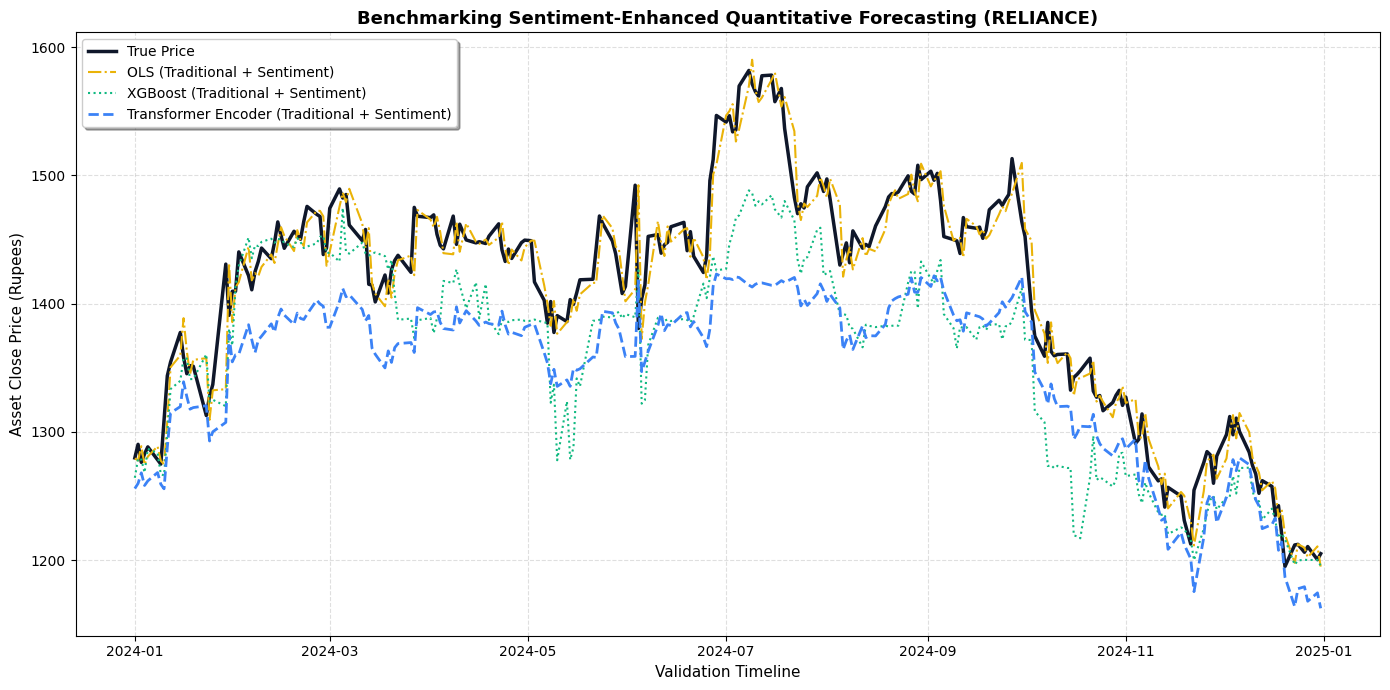

In [34]:
# CELL 10: Model Comparison and Visual Benchmarking

import matplotlib.pyplot as plt

# 1. Compile and display the global metric Scorecard Table
results_data = [
    {
        "Model Configuration": "OLS Linear Regression (Baseline)",
        "MSE": mean_squared_error(y_val_real, ols_base_preds),
        "MAE": mean_absolute_error(y_val_real, ols_base_preds),
        "R2 Score": r2_score(y_val_real, ols_base_preds),
        "Directional Accuracy": f"{dir_ols_base:.1f}%"
    },
    {
        "Model Configuration": "OLS Linear Regression (Sentiment-Enhanced)",
        "MSE": mean_squared_error(y_val_real, ols_sent_preds),
        "MAE": mean_absolute_error(y_val_real, ols_sent_preds),
        "R2 Score": r2_score(y_val_real, ols_sent_preds),
        "Directional Accuracy": f"{dir_ols_sent:.1f}%"
    },
    {
        "Model Configuration": "XGBoost Regressor (Baseline)",
        "MSE": mean_squared_error(y_val_real, xgb_base_preds),
        "MAE": mean_absolute_error(y_val_real, xgb_base_preds),
        "R2 Score": r2_score(y_val_real, xgb_base_preds),
        "Directional Accuracy": f"{dir_xgb_base:.1f}%"
    },
    {
        "Model Configuration": "XGBoost Regressor (Sentiment-Enhanced)",
        "MSE": mean_squared_error(y_val_real, xgb_sent_preds),
        "MAE": mean_absolute_error(y_val_real, xgb_sent_preds),
        "R2 Score": r2_score(y_val_real, xgb_sent_preds),
        "Directional Accuracy": f"{dir_xgb_sent:.1f}%"
    },
    {
        "Model Configuration": "Transformer Encoder (Baseline)",
        "MSE": mean_squared_error(y_val_real, transformer_base_preds),
        "MAE": mean_absolute_error(y_val_real, transformer_base_preds),
        "R2 Score": r2_score(y_val_real, transformer_base_preds),
        "Directional Accuracy": f"{dir_transformer_base:.1f}%"
    },
    {
        "Model Configuration": "Transformer Encoder (Sentiment-Enhanced)",
        "MSE": mean_squared_error(y_val_real, transformer_sent_preds),
        "MAE": mean_absolute_error(y_val_real, transformer_sent_preds),
        "R2 Score": r2_score(y_val_real, transformer_sent_preds),
        "Directional Accuracy": f"{dir_transformer_sent:.1f}%"
    }
]

df_results = pd.DataFrame(results_data)
display(df_results)

# 2. Visual Comparative Plotting for Target Asset (e.g., RELIANCE)
target_sym = "RELIANCE"
if target_sym in y_val_real_dict:
    # Retrieve target symbol-specific dates, unscaled actuals, and unscaled predictions
    df_sym = df_prepared[df_prepared['symbol'] == target_sym].reset_index(drop=True)
    X_a, y_a = sequences_a[target_sym]
    split_idx_a = int(len(X_a) * 0.8)
    val_dates = df_sym['date'].iloc[split_idx_a + 10:].values

    plt.figure(figsize=(14, 7))
    plt.plot(val_dates, y_val_real_dict[target_sym], label="True Price", color="#0f172a", linewidth=2.5)
    plt.plot(val_dates, ols_sent_preds_dict[target_sym], label="OLS (Traditional + Sentiment)", color="#eab308", linestyle="-.", linewidth=1.5)
    plt.plot(val_dates, xgb_sent_preds_dict[target_sym], label="XGBoost (Traditional + Sentiment)", color="#10b981", linestyle=":", linewidth=1.5)
    plt.plot(val_dates, transformer_sent_preds_dict[target_sym], label="Transformer Encoder (Traditional + Sentiment)", color="#3b82f6", linestyle="--", linewidth=2)

    plt.title(f"Benchmarking Sentiment-Enhanced Quantitative Forecasting ({target_sym})", fontsize=13, fontweight='bold')
    plt.xlabel("Validation Timeline", fontsize=11)
    plt.ylabel("Asset Close Price (Rupees)", fontsize=11)
    plt.legend(loc="upper left", frameon=True, shadow=True)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig("sentiment_evaluation.png", dpi=300)
    plt.show()
else:
    print(f"⚠️ Target symbol {target_sym} not found in validation split.")